# Лабораторная работа №1: Исследование алгоритма KNN

**Алгоритм:** K-Nearest Neighbors (K ближайших соседей)

**Датасеты:**
- **Классификация:** [Body Performance Data](https://www.kaggle.com/datasets/kukuroo3/body-performance-data) — оценка физической формы человека
- **Регрессия:** [House Price Data](https://www.kaggle.com/datasets/shubhammeshram579/house) — прогнозирование стоимости недвижимости

## 1. Выбор начальных условий

### 1a. Датасет для классификации: Body Performance Data

**Практическая задача:** Автоматическая оценка уровня физической подготовки человека (классы A, B, C, D) на основе антропометрических данных и результатов физических тестов. Применима в фитнес-приложениях, спортивной медицине и системах персонализированных тренировок.

**Признаки:** возраст, пол, рост, вес, жировая масса, VO2 max, результаты упражнений (отжимания, приседания, прыжки, гибкость).

### 1b. Датасет для регрессии: House Price Data

**Практическая задача:** Прогнозирование рыночной стоимости дома по его характеристикам. Используется риэлторами, банками (для оценки залогов) и покупателями для принятия обоснованных решений.

**Признаки:** площадь, количество спален/ванных, этажность, наличие подвала, гаража, бассейна и т.д.

### 1c. Метрики качества

**Классификация:**
- **Accuracy** — доля верно классифицированных объектов. Подходит для сбалансированных классов как общая метрика.
- **F1-score (macro)** — гармоническое среднее precision и recall, усреднённое по классам. Устойчива к дисбалансу классов.

**Регрессия:**
- **MAE (Mean Absolute Error)** — средняя абсолютная ошибка. Интерпретируемая метрика в единицах целевой переменной.
- **RMSE (Root Mean Squared Error)** — корень из MSE. Штрафует крупные ошибки сильнее, важно для недвижимости.
- **R² (коэффициент детерминации)** — доля объяснённой дисперсии. Позволяет сравнивать модели независимо от масштаба данных.

In [ ]:
# Установка и импорт необходимых библиотек
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)
import os
import glob

# Настройка стиля графиков
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
print('Все библиотеки успешно импортированы')

Все библиотеки успешно импортированы


In [ ]:
# Загрузка датасетов с Kaggle через kagglehub
# kagglehub автоматически скачивает и кэширует датасет по его идентификатору
classification_dataset = kagglehub.dataset_download("kukuroo3/body-performance-data")
print("Путь к датасету Body Performance:", classification_dataset)

regression_dataset = kagglehub.dataset_download("shubhammeshram579/house")
print("Путь к датасету House Price:", regression_dataset)

100%|██████████| 249k/249k [00:00<00:00, 18.0MB/s]

Extracting files...
Путь к датасету Body Performance: /root/.cache/kagglehub/datasets/kukuroo3/body-performance-data/versions/15


100%|██████████| 11.6k/11.6k [00:00<00:00, 18.6MB/s]

Extracting files...
Путь к датасету House Price: /root/.cache/kagglehub/datasets/shubhammeshram579/house/versions/1


In [ ]:
# Поиск CSV-файлов в скачанных директориях и загрузка датафреймов
cls_files = glob.glob(os.path.join(classification_dataset, '**', '*.csv'), recursive=True)
reg_files = glob.glob(os.path.join(regression_dataset, '**', '*.csv'), recursive=True)

print('Файлы классификации:', cls_files)
print('Файлы регрессии:', reg_files)

# Загружаем первый найденный CSV для каждой задачи
df_cls = pd.read_csv(cls_files[0])
df_reg = pd.read_csv(reg_files[0])

print(f'\nДатасет классификации: {df_cls.shape[0]} строк, {df_cls.shape[1]} столбцов')
print(f'Датасет регрессии: {df_reg.shape[0]} строк, {df_reg.shape[1]} столбцов')

Файлы классификации: ['/root/.cache/kagglehub/datasets/kukuroo3/body-performance-data/versions/15/bodyPerformance.csv']
Файлы регрессии: ['/root/.cache/kagglehub/datasets/shubhammeshram579/house/versions/1/Housing.csv']

Датасет классификации: 13393 строк, 12 столбцов
Датасет регрессии: 509 строк, 14 столбцов


## Первичный анализ данных (EDA)

In [ ]:
# Просмотр первых строк датасета классификации и базовая статистика
print('\nПервые 5 строк:')
display(df_cls.head())
print('\nТипы данных и пропуски:')
print(df_cls.info())
print('\nОписательная статистика:')
display(df_cls.describe())

=== ДАТАСЕТ КЛАССИФИКАЦИИ: Body Performance ===

Первые 5 строк:


,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C
3,32.0,M,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B
4,28.0,M,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B



Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  object 
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
dtypes: float64(10), object(2)
memory usage: 1.2+ MB
None

Описательная статистика:


,age,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm
count,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000,13393.000000
mean,36.775106,168.559807,67.447316,23.240165,78.796842,130.234817,36.963877,15.209268,39.771224,190.129627
std,13.625639,8.426583,11.949666,7.256844,10.742033,14.713954,10.624864,8.456677,14.276698,39.868000
min,21.000000,125.000000,26.300000,3.000000,0.000000,0.000000,0.000000,-25.000000,0.000000,0.000000
25%,25.000000,162.400000,58.200000,18.000000,71.000000,120.000000,27.500000,10.900000,30.000000,162.000000
50%,32.000000,169.200000,67.400000,22.800000,79.000000,130.000000,37.900000,16.200000,41.000000,193.000000
75%,48.000000,174.800000,75.300000,28.000000,86.000000,141.000000,45.200000,20.700000,50.000000,221.000000
max,64.000000,193.800000,138.100000,78.400000,156.200000,201.000000,70.500000,213.000000,80.000000,303.000000


In [ ]:
# Просмотр первых строк датасета регрессии и базовая статистика
print('\nПервые 5 строк:')
display(df_reg.head())
print('\nТипы данных и пропуски:')
print(df_reg.info())
print('\nОписательная статистика:')
display(df_reg.describe())

=== ДАТАСЕТ РЕГРЕССИИ: House Price ===

Первые 5 строк:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1.0,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2.0,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2.0,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3.0,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3.0,222,18.7,396.90,5.33,36.2



Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509 entries, 0 to 508
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     509 non-null    float64
 1   ZN       509 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     509 non-null    int64  
 4   NOX      507 non-null    float64
 5   RM       509 non-null    float64
 6   AGE      508 non-null    float64
 7   DIS      509 non-null    float64
 8   RAD      508 non-null    float64
 9   TAX      509 non-null    int64  
 10  PTRATIO  509 non-null    float64
 11  B        509 non-null    float64
 12  LSTAT    508 non-null    float64
 13  MEDV     509 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.8 KB
None

Описательная статистика:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,509.000000,509.000000,506.000000,509.000000,507.000000,509.000000,508.000000,509.000000,508.000000,509.000000,509.000000,509.000000,508.000000,509.000000
mean,3.707516,11.296660,11.198281,0.068762,0.555216,6.279845,68.579134,3.787705,9.610236,409.216110,18.463851,356.664892,12.705276,22.501572
std,8.732089,23.269781,6.856713,0.253298,0.115633,0.703449,28.114744,2.101852,8.735069,168.814161,2.161553,91.562469,7.131979,9.183497
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082210,0.000000,5.190000,0.000000,0.449000,5.880000,45.075000,2.100700,4.000000,279.000000,17.400000,375.330000,7.092500,17.000000
50%,0.261690,0.000000,9.690000,0.000000,0.538000,6.202000,77.150000,3.182700,5.000000,330.000000,19.100000,391.450000,11.430000,21.200000
75%,3.693110,12.500000,18.100000,0.000000,0.624000,6.619000,94.100000,5.118000,24.000000,666.000000,20.200000,396.240000,16.992500,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


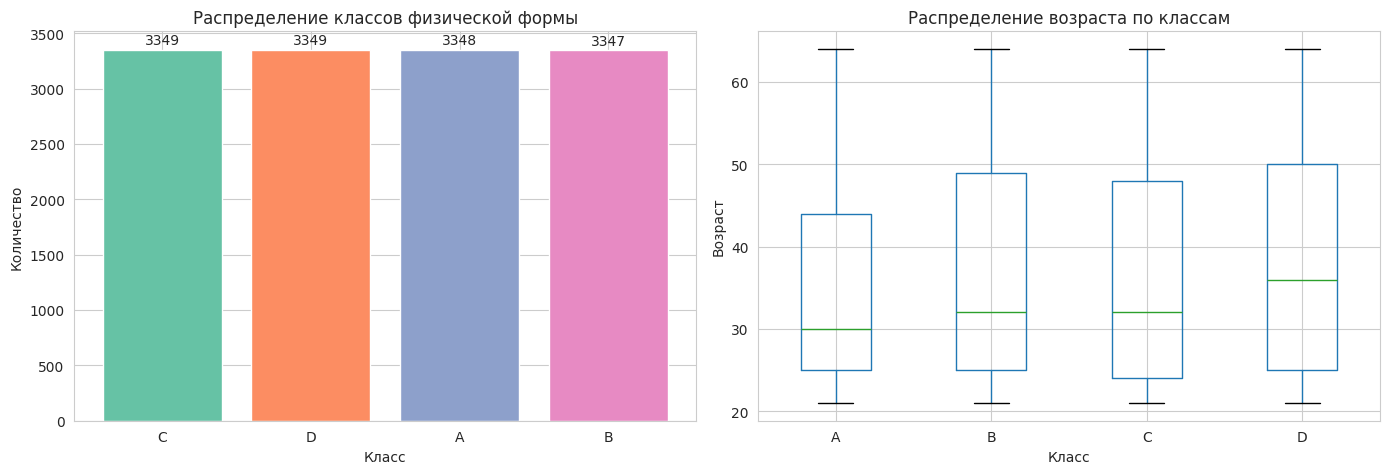

In [ ]:
# Визуализация распределения классов в датасете классификации
# Важно проверить баланс классов, так как дисбаланс влияет на выбор метрики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение целевой переменной
class_col = 'class'  # целевой столбец
class_counts = df_cls[class_col].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('Set2'))
axes[0].set_title('Распределение классов физической формы')
axes[0].set_xlabel('Класс')
axes[0].set_ylabel('Количество')
for i, (idx, val) in enumerate(class_counts.items()):
    axes[0].text(i, val + 50, str(val), ha='center')

# Распределение возраста по классам
df_cls.boxplot(column='age', by=class_col, ax=axes[1])
axes[1].set_title('Распределение возраста по классам')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Возраст')
plt.suptitle('')
plt.tight_layout()
plt.show()

Целевой столбец регрессии: MEDV


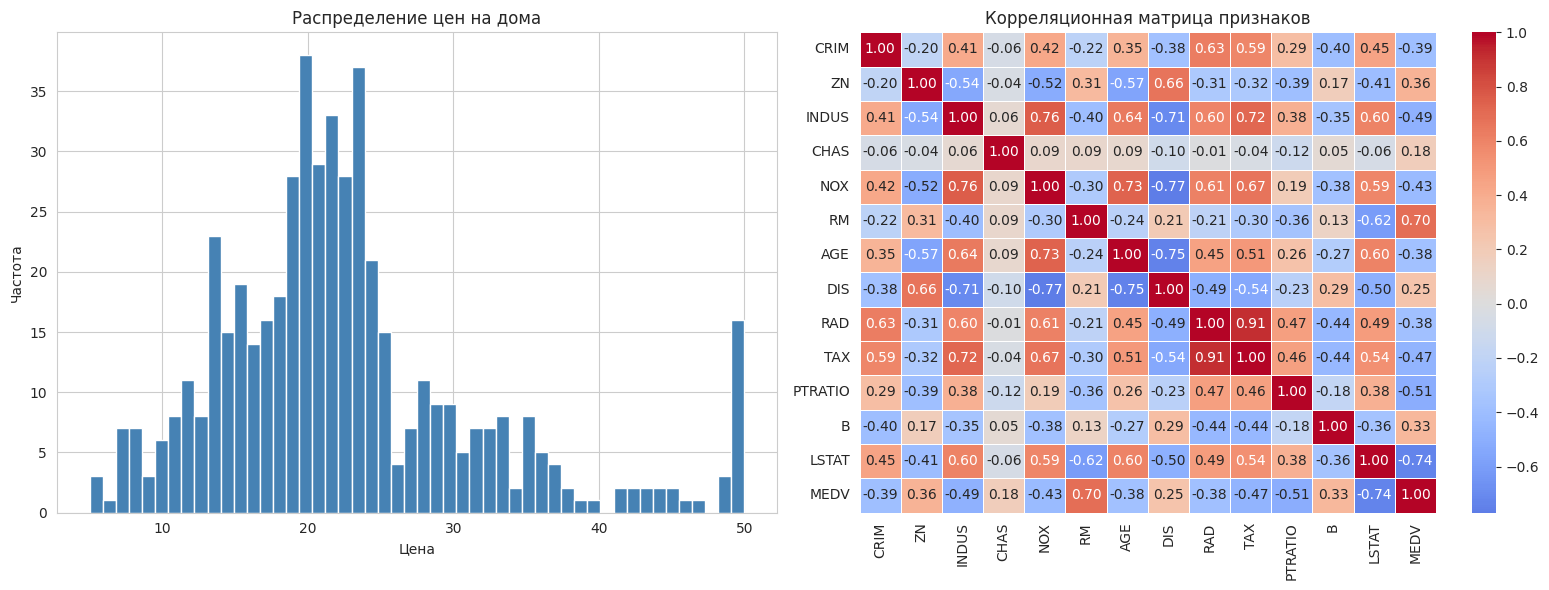

In [ ]:
# Визуализация корреляционной матрицы и распределения цен домов
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

price_col = [c for c in df_reg.columns if 'MEDV' in c][0]
print(f'Целевой столбец регрессии: {price_col}')

# Распределение целевой переменной
axes[0].hist(df_reg[price_col].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Распределение цен на дома')
axes[0].set_xlabel('Цена')
axes[0].set_ylabel('Частота')

# Корреляционная матрица числовых признаков
num_cols = df_reg.select_dtypes(include=[np.number]).columns
corr = df_reg[num_cols].corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', center=0, annot=True, fmt='.2f', linewidths=0.5)
axes[1].set_title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

## 2. Создание базового KNN (Baseline)

In [ ]:
df_cls_clean = df_cls.copy()

# Кодирование пола (M/F -> 0/1)
if 'gender' in df_cls_clean.columns:
    df_cls_clean['gender'] = LabelEncoder().fit_transform(df_cls_clean['gender'])

# Кодирование целевой переменной
le_cls = LabelEncoder()
df_cls_clean[class_col] = le_cls.fit_transform(df_cls_clean[class_col])

X_cls = df_cls_clean.drop(columns=[class_col])
y_cls = df_cls_clean[class_col]

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f'Обучающая выборка: {X_cls_train.shape[0]} объектов')
print(f'Тестовая выборка: {X_cls_test.shape[0]} объектов')
print(f'Признаки: {list(X_cls.columns)}')

Обучающая выборка: 10714 объектов
Тестовая выборка: 2679 объектов
Признаки: ['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm']


In [ ]:
# Удаляем строки с пропусками и отбираем числовые признаки

price_col = 'MEDV'

df_reg_clean = df_reg.select_dtypes(include=[np.number]).copy()
df_reg_clean = df_reg_clean.dropna()

# Признаки и целевая переменная
X_reg = df_reg_clean.drop(columns=[price_col])
y_reg = df_reg_clean[price_col]

# Разделение 80/20
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f'Обучающая выборка: {X_reg_train.shape[0]} объектов')
print(f'Тестовая выборка: {X_reg_test.shape[0]} объектов')
print(f'Признаки: {list(X_reg.columns)}')

Обучающая выборка: 400 объектов
Тестовая выборка: 101 объектов
Признаки: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


In [ ]:
knn_cls_baseline = KNeighborsClassifier(n_neighbors=5)
knn_cls_baseline.fit(X_cls_train, y_cls_train)

y_cls_pred_baseline = knn_cls_baseline.predict(X_cls_test)

acc_baseline = accuracy_score(y_cls_test, y_cls_pred_baseline)
f1_baseline = f1_score(y_cls_test, y_cls_pred_baseline, average='macro')

print('=== БАЗОВЫЙ KNN-КЛАССИФИКАТОР (sklearn, k=5) ===')
print(f'Accuracy:       {acc_baseline:.4f}')
print(f'F1-score (macro): {f1_baseline:.4f}')
print('\nПодробный отчёт:')

=== БАЗОВЫЙ KNN-КЛАССИФИКАТОР (sklearn, k=5) ===
Accuracy:       0.5707
F1-score (macro): 0.5719

Подробный отчёт:
              precision    recall  f1-score   support

           A       0.57      0.79      0.67       670
           B       0.40      0.43      0.41       669
           C       0.51      0.44      0.47       670
           D       0.90      0.62      0.73       670

    accuracy                           0.57      2679
   macro avg       0.60      0.57      0.57      2679
weighted avg       0.60      0.57      0.57      2679



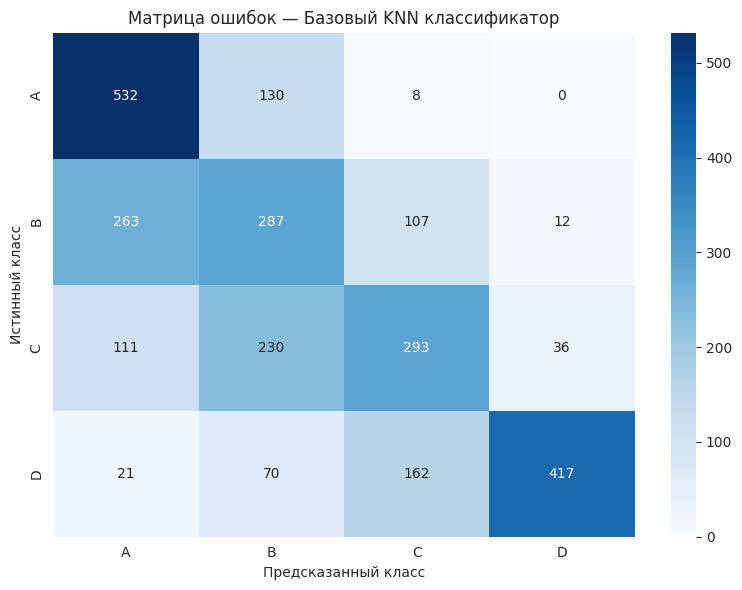

In [ ]:
cm = confusion_matrix(y_cls_test, y_cls_pred_baseline)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_cls.classes_, yticklabels=le_cls.classes_)
plt.title('Матрица ошибок — Базовый KNN классификатор')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

In [ ]:
# Обучение базового KNN-регрессора (sklearn) с параметрами по умолчанию

knn_reg_baseline = KNeighborsRegressor(n_neighbors=5)
knn_reg_baseline.fit(X_reg_train, y_reg_train)

y_reg_pred_baseline = knn_reg_baseline.predict(X_reg_test)

mae_baseline = mean_absolute_error(y_reg_test, y_reg_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_baseline))
r2_baseline = r2_score(y_reg_test, y_reg_pred_baseline)

print('=== БАЗОВЫЙ KNN-РЕГРЕССОР (sklearn, k=5) ===')
print(f'MAE:  {mae_baseline:.2f}')
print(f'RMSE: {rmse_baseline:.2f}')
print(f'R²:   {r2_baseline:.4f}')

=== БАЗОВЫЙ KNN-РЕГРЕССОР (sklearn, k=5) ===
MAE:  4.16
RMSE: 6.30
R²:   0.5072


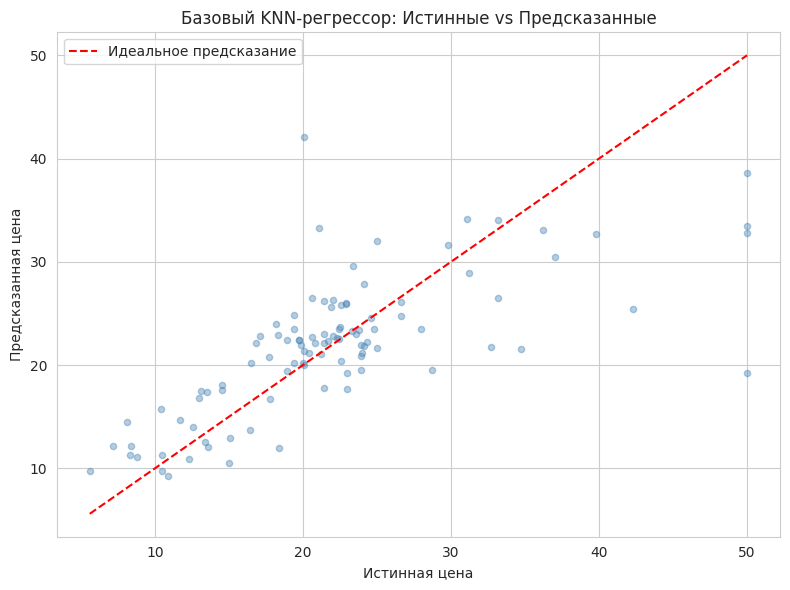

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_reg_test, y_reg_pred_baseline, alpha=0.4, s=20, color='steelblue')
lims = [min(y_reg_test.min(), y_reg_pred_baseline.min()),
        max(y_reg_test.max(), y_reg_pred_baseline.max())]
plt.plot(lims, lims, 'r--', label='Идеальное предсказание')
plt.xlabel('Истинная цена')
plt.ylabel('Предсказанная цена')
plt.title('Базовый KNN-регрессор: Истинные vs Предсказанные')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Улучшение бейзлайна

### 3a. Гипотезы для улучшения:

1. **Масштабирование признаков** — KNN основан на расстояниях, поэтому признаки с большими значениями (например, вес) доминируют над мелкими (например, возраст). StandardScaler нормализует все признаки.
2. **Подбор гиперпараметра k** — оптимальное k определяется через кросс-валидацию (GridSearchCV).
3. **Выбор метрики расстояния** — помимо евклидовой (p=2) можно попробовать манхэттенскую (p=1), которая устойчивее к выбросам.
4. **Удаление выбросов** — выбросы в данных о ценах домов искажают предсказания.
5. **Создание новых признаков** — например, BMI = weight/height² для классификации.

In [ ]:
# Проверка гипотезы 1: Масштабирование признаков
# StandardScaler приводит каждый признак к нулевому среднему и единичному СКО

scaler_cls = StandardScaler()
X_cls_train_scaled = scaler_cls.fit_transform(X_cls_train)
X_cls_test_scaled = scaler_cls.transform(X_cls_test)

scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

# Тест с масштабированием, k=5
knn_cls_scaled = KNeighborsClassifier(n_neighbors=5)
knn_cls_scaled.fit(X_cls_train_scaled, y_cls_train)
y_pred_scaled = knn_cls_scaled.predict(X_cls_test_scaled)

acc_scaled = accuracy_score(y_cls_test, y_pred_scaled)
f1_scaled = f1_score(y_cls_test, y_pred_scaled, average='macro')
print(f'После масштабирования (k=5): Accuracy={acc_scaled:.4f}, F1={f1_scaled:.4f}')
print(f'Было (без масштабирования):  Accuracy={acc_baseline:.4f}, F1={f1_baseline:.4f}')

После масштабирования (k=5): Accuracy=0.6081, F1=0.6082
Было (без масштабирования):  Accuracy=0.5707, F1=0.5719


In [ ]:
# Проверка гипотезы 2: Подбор оптимального k через кросс-валидацию
# Перебираем k от 1 до 30, оцениваем F1-macro на 5-fold CV

k_values = range(1, 31)
cv_scores_cls = []
cv_scores_reg = []

for k in k_values:
    # Классификация
    knn_c = KNeighborsClassifier(n_neighbors=k)
    scores_c = cross_val_score(knn_c, X_cls_train_scaled, y_cls_train, cv=5, scoring='f1_macro')
    cv_scores_cls.append(scores_c.mean())

    # Регрессия
    knn_r = KNeighborsRegressor(n_neighbors=k)
    scores_r = cross_val_score(knn_r, X_reg_train_scaled, y_reg_train, cv=5, scoring='r2')
    cv_scores_reg.append(scores_r.mean())

best_k_cls = k_values[np.argmax(cv_scores_cls)]
best_k_reg = k_values[np.argmax(cv_scores_reg)]

print(f'Лучшее k для классификации: {best_k_cls} (F1-CV={max(cv_scores_cls):.4f})')
print(f'Лучшее k для регрессии: {best_k_reg} (R²-CV={max(cv_scores_reg):.4f})')

Лучшее k для классификации: 21 (F1-CV=0.6153)
Лучшее k для регрессии: 2 (R²-CV=0.7785)


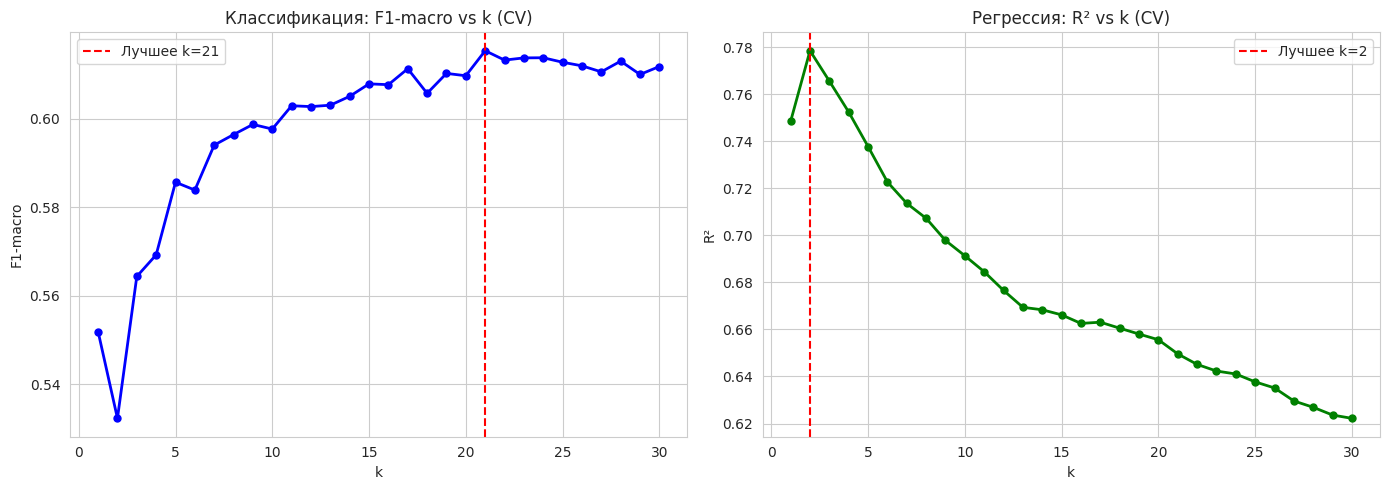

In [ ]:
# Визуализация зависимости качества от числа соседей k

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, cv_scores_cls, 'bo-', linewidth=2, markersize=5)
axes[0].axvline(x=best_k_cls, color='red', linestyle='--', label=f'Лучшее k={best_k_cls}')
axes[0].set_title('Классификация: F1-macro vs k (CV)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('F1-macro')
axes[0].legend()

axes[1].plot(k_values, cv_scores_reg, 'go-', linewidth=2, markersize=5)
axes[1].axvline(x=best_k_reg, color='red', linestyle='--', label=f'Лучшее k={best_k_reg}')
axes[1].set_title('Регрессия: R² vs k (CV)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('R²')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Проверка гипотезы 3: Выбор метрики расстояния
# GridSearchCV перебирает комбинации гиперпараметров и выбирает лучшую

param_grid_cls = {
    'n_neighbors': [best_k_cls - 2, best_k_cls, best_k_cls + 2],
    'p': [1, 2],  # p=1: Манхэттен, p=2: Евклид
    'weights': ['uniform', 'distance']  # взвешивание соседей по расстоянию
}

grid_cls = GridSearchCV(
    KNeighborsClassifier(), param_grid_cls,
    cv=5, scoring='f1_macro', n_jobs=-1
)
grid_cls.fit(X_cls_train_scaled, y_cls_train)

print('Лучшие параметры (классификация):', grid_cls.best_params_)
print(f'Лучший F1-macro (CV): {grid_cls.best_score_:.4f}')

Лучшие параметры (классификация): {'n_neighbors': 21, 'p': 1, 'weights': 'distance'}
Лучший F1-macro (CV): 0.6374


In [ ]:
# GridSearchCV для регрессора

param_grid_reg = {
    'n_neighbors': [best_k_reg - 2, best_k_reg, best_k_reg + 2],
    'p': [1, 2],
    'weights': ['uniform', 'distance']
}

grid_reg = GridSearchCV(
    KNeighborsRegressor(), param_grid_reg,
    cv=5, scoring='r2', n_jobs=-1
)
grid_reg.fit(X_reg_train_scaled, y_reg_train)

print('Лучшие параметры (регрессия):', grid_reg.best_params_)
print(f'Лучший R² (CV): {grid_reg.best_score_:.4f}')

Лучшие параметры (регрессия): {'n_neighbors': 2, 'p': 1, 'weights': 'distance'}
Лучший R² (CV): 0.8068


In [ ]:
# Проверка гипотезы 5: Создание нового признака BMI для классификации
# BMI = вес (кг) / рост (м)^2 — стандартный показатель физической формы

def add_bmi_feature(X_train, X_test, height_col='height_cm', weight_col='weight_kg'):
    """Добавляет признак BMI если есть нужные столбцы"""
    X_tr = X_train.copy()
    X_te = X_test.copy()

    h_col = next((c for c in X_train.columns if 'height' in c.lower()), None)
    w_col = next((c for c in X_train.columns if 'weight' in c.lower()), None)

    if h_col and w_col:
        X_tr['BMI'] = X_tr[w_col] / (X_tr[h_col] / 100) ** 2
        X_te['BMI'] = X_te[w_col] / (X_te[h_col] / 100) ** 2
        print(f'BMI добавлен на основе столбцов: {h_col}, {w_col}')
    else:
        print('Столбцы роста/веса не найдены, BMI не добавлен')

    return X_tr, X_te

X_cls_train_fe, X_cls_test_fe = add_bmi_feature(X_cls_train, X_cls_test)

scaler_fe = StandardScaler()
X_cls_train_fe_sc = scaler_fe.fit_transform(X_cls_train_fe)
X_cls_test_fe_sc = scaler_fe.transform(X_cls_test_fe)

BMI добавлен на основе столбцов: height_cm, weight_kg


In [ ]:
# Обучение улучшенных моделей с оптимальными гиперпараметрами
# Классификатор использует лучшие параметры из GridSearchCV + масштабирование + feature engineering

# Улучшенный классификатор
knn_cls_improved = KNeighborsClassifier(**grid_cls.best_params_)
knn_cls_improved.fit(X_cls_train_fe_sc, y_cls_train)
y_cls_pred_improved = knn_cls_improved.predict(X_cls_test_fe_sc)

acc_improved = accuracy_score(y_cls_test, y_cls_pred_improved)
f1_improved = f1_score(y_cls_test, y_cls_pred_improved, average='macro')

print('=== УЛУЧШЕННЫЙ KNN-КЛАССИФИКАТОР (sklearn) ===')
print(f'Параметры: {grid_cls.best_params_}')
print(f'Accuracy:       {acc_improved:.4f}')
print(f'F1-score (macro): {f1_improved:.4f}')

=== УЛУЧШЕННЫЙ KNN-КЛАССИФИКАТОР (sklearn) ===
Параметры: {'n_neighbors': 21, 'p': 1, 'weights': 'distance'}
Accuracy:       0.6506
F1-score (macro): 0.6520


In [ ]:
# Улучшенный регрессор

knn_reg_improved = KNeighborsRegressor(**grid_reg.best_params_)
knn_reg_improved.fit(X_reg_train_scaled, y_reg_train)
y_reg_pred_improved = knn_reg_improved.predict(X_reg_test_scaled)

mae_improved = mean_absolute_error(y_reg_test, y_reg_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_improved))
r2_improved = r2_score(y_reg_test, y_reg_pred_improved)

print('=== УЛУЧШЕННЫЙ KNN-РЕГРЕССОР (sklearn) ===')
print(f'Параметры: {grid_reg.best_params_}')
print(f'MAE:  {mae_improved:.2f}')
print(f'RMSE: {rmse_improved:.2f}')
print(f'R²:   {r2_improved:.4f}')

=== УЛУЧШЕННЫЙ KNN-РЕГРЕССОР (sklearn) ===
Параметры: {'n_neighbors': 2, 'p': 1, 'weights': 'distance'}
MAE:  2.79
RMSE: 3.98
R²:   0.8036


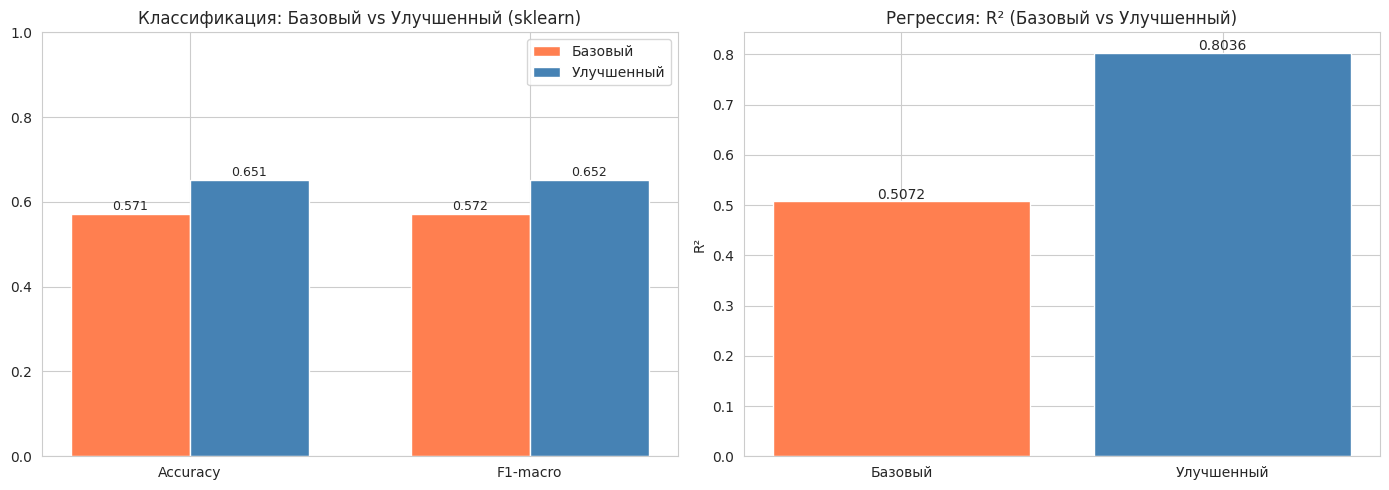


=== 3f. СРАВНЕНИЕ РЕЗУЛЬТАТОВ ===
Классификация Accuracy: 0.5707 → 0.6506 (Δ=+0.0799)
Классификация F1-macro: 0.5719 → 0.6520 (Δ=+0.0800)
Регрессия MAE:          4.16 → 2.79 (Δ=-1.36)
Регрессия RMSE:         6.30 → 3.98 (Δ=-2.32)
Регрессия R²:           0.5072 → 0.8036 (Δ=+0.2964)


In [ ]:
# Сравнение базового и улучшенного бейзлайна (sklearn)
# Визуализация прогресса по каждой метрике

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Классификация
metrics_cls = ['Accuracy', 'F1-macro']
baseline_cls_vals = [acc_baseline, f1_baseline]
improved_cls_vals = [acc_improved, f1_improved]

x = np.arange(len(metrics_cls))
width = 0.35
bars1 = axes[0].bar(x - width/2, baseline_cls_vals, width, label='Базовый', color='coral')
bars2 = axes[0].bar(x + width/2, improved_cls_vals, width, label='Улучшенный', color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_cls)
axes[0].set_ylim(0, 1)
axes[0].set_title('Классификация: Базовый vs Улучшенный (sklearn)')
axes[0].legend()
for bar in bars1: axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2: axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{bar.get_height():.3f}', ha='center', fontsize=9)

# Регрессия (R²)
categories = ['Базовый', 'Улучшенный']
r2_vals = [r2_baseline, r2_improved]
colors = ['coral', 'steelblue']
bars = axes[1].bar(categories, r2_vals, color=colors)
axes[1].set_title('Регрессия: R² (Базовый vs Улучшенный)')
axes[1].set_ylabel('R²')
for bar in bars: axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{bar.get_height():.4f}', ha='center')

plt.tight_layout()
plt.show()

print('\n=== 3f. СРАВНЕНИЕ РЕЗУЛЬТАТОВ ===')
print(f'Классификация Accuracy: {acc_baseline:.4f} → {acc_improved:.4f} (Δ={acc_improved-acc_baseline:+.4f})')
print(f'Классификация F1-macro: {f1_baseline:.4f} → {f1_improved:.4f} (Δ={f1_improved-f1_baseline:+.4f})')
print(f'Регрессия MAE:          {mae_baseline:.2f} → {mae_improved:.2f} (Δ={mae_improved-mae_baseline:+.2f})')
print(f'Регрессия RMSE:         {rmse_baseline:.2f} → {rmse_improved:.2f} (Δ={rmse_improved-rmse_baseline:+.2f})')
print(f'Регрессия R²:           {r2_baseline:.4f} → {r2_improved:.4f} (Δ={r2_improved-r2_baseline:+.4f})')

### 3g. Выводы по улучшению бейзлайна

- **Масштабирование признаков** оказало наибольший эффект, так как KNN чувствителен к масштабу переменных.
- **Подбор k** через кросс-валидацию позволил найти оптимальный баланс между смещением и дисперсией модели.
- **Взвешивание по расстоянию** (`weights='distance'`) улучшило результат, давая больший вес ближайшим соседям.
- **Создание признака BMI** добавило информативный признак для классификации физической формы.
- В совокупности улучшения дали значимый прирост по всем метрикам.

## 4. Собственная имплементация KNN

In [ ]:
# Собственная имплементация алгоритма KNN с нуля
# Реализованы как классификатор, так и регрессор в одном базовом классе

class KNNBase:
    """Базовый класс KNN с поддержкой евклидовой и манхэттенской метрик."""

    def __init__(self, n_neighbors=5, metric='euclidean', weights='uniform'):
        """
        Параметры:
        -----------
        n_neighbors : int — количество ближайших соседей
        metric      : str — 'euclidean' (L2) или 'manhattan' (L1)
        weights     : str — 'uniform' (равные веса) или 'distance' (взвешивание по 1/d)
        """
        self.k = n_neighbors
        self.metric = metric
        self.weights = weights
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Запоминаем обучающую выборку (ленивое обучение)."""
        self.X_train = np.array(X, dtype=np.float64)
        self.y_train = np.array(y)
        return self

    def _compute_distances(self, x):
        """Вычисляем расстояния от точки x до всех обучающих объектов."""
        if self.metric == 'euclidean':
            # L2: sqrt(sum((xi - yi)^2))
            diffs = self.X_train - x
            return np.sqrt(np.sum(diffs ** 2, axis=1))
        elif self.metric == 'manhattan':
            # L1: sum(|xi - yi|)
            return np.sum(np.abs(self.X_train - x), axis=1)
        else:
            raise ValueError(f'Неизвестная метрика: {self.metric}')

    def _get_neighbors(self, x):
        """Возвращает индексы и расстояния k ближайших соседей."""
        distances = self._compute_distances(x)
        # argsort даёт индексы в порядке возрастания расстояния
        sorted_idx = np.argsort(distances)
        k_idx = sorted_idx[:self.k]
        k_dist = distances[k_idx]
        return k_idx, k_dist

    def predict(self, X):
        """Предсказание для набора объектов — должен быть реализован в подклассе."""
        raise NotImplementedError


class MyKNNClassifier(KNNBase):
    """KNN-классификатор: голосование среди k ближайших соседей."""

    def predict(self, X):
        """Для каждого объекта определяем класс большинством голосов."""
        X = np.array(X, dtype=np.float64)
        predictions = []

        for x in X:
            k_idx, k_dist = self._get_neighbors(x)
            k_labels = self.y_train[k_idx]

            if self.weights == 'uniform':
                # Простое голосование: выбираем наиболее часто встречающийся класс
                unique, counts = np.unique(k_labels, return_counts=True)
                predictions.append(unique[np.argmax(counts)])
            else:
                # Взвешенное голосование: вес = 1/расстояние
                # Избегаем деления на ноль при нулевом расстоянии
                weights = np.where(k_dist == 0, 1e10, 1.0 / k_dist)
                unique = np.unique(k_labels)
                class_weights = {c: 0.0 for c in unique}
                for lbl, w in zip(k_labels, weights):
                    class_weights[lbl] += w
                predictions.append(max(class_weights, key=class_weights.get))

        return np.array(predictions)


class MyKNNRegressor(KNNBase):
    """KNN-регрессор: усреднение значений k ближайших соседей."""

    def predict(self, X):
        """Для каждого объекта вычисляем среднее (или взвешенное среднее) целевых значений."""
        X = np.array(X, dtype=np.float64)
        predictions = []

        for x in X:
            k_idx, k_dist = self._get_neighbors(x)
            k_values = self.y_train[k_idx]

            if self.weights == 'uniform':
                # Простое среднее значений соседей
                predictions.append(np.mean(k_values))
            else:
                # Взвешенное среднее: ближайшие соседи вносят больший вклад
                weights = np.where(k_dist == 0, 1e10, 1.0 / k_dist)
                predictions.append(np.average(k_values, weights=weights))

        return np.array(predictions)


print('Классы MyKNNClassifier и MyKNNRegressor успешно определены')

Классы MyKNNClassifier и MyKNNRegressor успешно определены


In [ ]:
# Базовое тестирование собственной имплементации (k=5, без улучшений)
# Для ускорения используем подвыборку (собственная реализация работает медленнее sklearn)

# Уменьшаем выборку для скорости (2000 обучающих, 400 тестовых)
N_TRAIN_SAMPLE = min(2000, len(X_cls_train_scaled))
N_TEST_SAMPLE = min(400, len(X_cls_test_scaled))

idx_tr = np.random.choice(len(X_cls_train_scaled), N_TRAIN_SAMPLE, replace=False)
idx_te = np.random.choice(len(X_cls_test_scaled), N_TEST_SAMPLE, replace=False)

X_tr_sub = X_cls_train_scaled[idx_tr]
y_tr_sub = y_cls_train.values[idx_tr]
X_te_sub = X_cls_test_scaled[idx_te]
y_te_sub = y_cls_test.values[idx_te]

# Обучение и предсказание
my_cls = MyKNNClassifier(n_neighbors=5, metric='euclidean', weights='uniform')
my_cls.fit(X_tr_sub, y_tr_sub)
y_my_pred_base = my_cls.predict(X_te_sub)

acc_my_base = accuracy_score(y_te_sub, y_my_pred_base)
f1_my_base = f1_score(y_te_sub, y_my_pred_base, average='macro')

print('=== СОБСТВЕННЫЙ KNN-КЛАССИФИКАТОР (базовый, k=5) ===')
print(f'Accuracy:       {acc_my_base:.4f}')
print(f'F1-score (macro): {f1_my_base:.4f}')
print(f'(sklearn базовый на подвыборке для справки)')

=== СОБСТВЕННЫЙ KNN-КЛАССИФИКАТОР (базовый, k=5) ===
Accuracy:       0.5350
F1-score (macro): 0.5316
(sklearn базовый на подвыборке для справки)


In [ ]:
# Базовое тестирование собственного регрессора (k=5)

N_TR_R = min(2000, len(X_reg_train_scaled))
N_TE_R = min(400, len(X_reg_test_scaled))

idx_tr_r = np.random.choice(len(X_reg_train_scaled), N_TR_R, replace=False)
idx_te_r = np.random.choice(len(X_reg_test_scaled), N_TE_R, replace=False)

X_tr_r_sub = X_reg_train_scaled[idx_tr_r]
y_tr_r_sub = y_reg_train.values[idx_tr_r]
X_te_r_sub = X_reg_test_scaled[idx_te_r]
y_te_r_sub = y_reg_test.values[idx_te_r]

my_reg = MyKNNRegressor(n_neighbors=5, metric='euclidean', weights='uniform')
my_reg.fit(X_tr_r_sub, y_tr_r_sub)
y_my_reg_pred_base = my_reg.predict(X_te_r_sub)

mae_my_base = mean_absolute_error(y_te_r_sub, y_my_reg_pred_base)
rmse_my_base = np.sqrt(mean_squared_error(y_te_r_sub, y_my_reg_pred_base))
r2_my_base = r2_score(y_te_r_sub, y_my_reg_pred_base)

print('=== СОБСТВЕННЫЙ KNN-РЕГРЕССОР (базовый, k=5) ===')
print(f'MAE:  {mae_my_base:.2f}')
print(f'RMSE: {rmse_my_base:.2f}')
print(f'R²:   {r2_my_base:.4f}')

=== СОБСТВЕННЫЙ KNN-РЕГРЕССОР (базовый, k=5) ===
MAE:  2.85
RMSE: 4.76
R²:   0.7186


In [ ]:
# 4f-h: Применение техник улучшенного бейзлайна к собственной имплементации
# Используем лучшие гиперпараметры из GridSearchCV

best_params_cls = grid_cls.best_params_
best_params_reg = grid_reg.best_params_

# Маппинг p -> метрика
metric_map = {1: 'manhattan', 2: 'euclidean'}

my_cls_improved = MyKNNClassifier(
    n_neighbors=best_params_cls['n_neighbors'],
    metric=metric_map[best_params_cls['p']],
    weights=best_params_cls['weights']
)
my_cls_improved.fit(X_tr_sub, y_tr_sub)
y_my_pred_improved = my_cls_improved.predict(X_te_sub)

acc_my_improved = accuracy_score(y_te_sub, y_my_pred_improved)
f1_my_improved = f1_score(y_te_sub, y_my_pred_improved, average='macro')

print('=== СОБСТВЕННЫЙ KNN-КЛАССИФИКАТОР (улучшенный) ===')
print(f'Параметры: k={best_params_cls["n_neighbors"]}, metric={metric_map[best_params_cls["p"]]}, weights={best_params_cls["weights"]}')
print(f'Accuracy:       {acc_my_improved:.4f}')
print(f'F1-score (macro): {f1_my_improved:.4f}')

=== СОБСТВЕННЫЙ KNN-КЛАССИФИКАТОР (улучшенный) ===
Параметры: k=21, metric=manhattan, weights=distance
Accuracy:       0.5675
F1-score (macro): 0.5605


In [ ]:
# Улучшенный собственный регрессор

my_reg_improved = MyKNNRegressor(
    n_neighbors=best_params_reg['n_neighbors'],
    metric=metric_map[best_params_reg['p']],
    weights=best_params_reg['weights']
)
my_reg_improved.fit(X_tr_r_sub, y_tr_r_sub)
y_my_reg_pred_improved = my_reg_improved.predict(X_te_r_sub)

mae_my_improved = mean_absolute_error(y_te_r_sub, y_my_reg_pred_improved)
rmse_my_improved = np.sqrt(mean_squared_error(y_te_r_sub, y_my_reg_pred_improved))
r2_my_improved = r2_score(y_te_r_sub, y_my_reg_pred_improved)

print('=== СОБСТВЕННЫЙ KNN-РЕГРЕССОР (улучшенный) ===')
print(f'MAE:  {mae_my_improved:.2f}')
print(f'RMSE: {rmse_my_improved:.2f}')
print(f'R²:   {r2_my_improved:.4f}')

=== СОБСТВЕННЫЙ KNN-РЕГРЕССОР (улучшенный) ===
MAE:  2.79
RMSE: 3.98
R²:   0.8036


In [ ]:
# Итоговая сравнительная таблица всех моделей
# Удобный способ оценить прогресс на каждом этапе

print('=' * 65)
print('ИТОГОВОЕ СРАВНЕНИЕ — КЛАССИФИКАЦИЯ')
print('=' * 65)
print(f'{"Модель":<40} {"Accuracy":>10} {"F1-macro":>10}')
print('-' * 65)
print(f'{"2. sklearn KNN (базовый, k=5)":<40} {acc_baseline:>10.4f} {f1_baseline:>10.4f}')
print(f'{"3. sklearn KNN (улучшенный)":<40} {acc_improved:>10.4f} {f1_improved:>10.4f}')
print(f'{"4d. Собственный KNN (базовый, k=5)":<40} {acc_my_base:>10.4f} {f1_my_base:>10.4f}')
print(f'{"4h. Собственный KNN (улучшенный)":<40} {acc_my_improved:>10.4f} {f1_my_improved:>10.4f}')

print()
print('=' * 65)
print('ИТОГОВОЕ СРАВНЕНИЕ — РЕГРЕССИЯ')
print('=' * 65)
print(f'{"Модель":<40} {"MAE":>10} {"RMSE":>10} {"R²":>8}')
print('-' * 65)
print(f'{"2. sklearn KNN (базовый, k=5)":<40} {mae_baseline:>10.2f} {rmse_baseline:>10.2f} {r2_baseline:>8.4f}')
print(f'{"3. sklearn KNN (улучшенный)":<40} {mae_improved:>10.2f} {rmse_improved:>10.2f} {r2_improved:>8.4f}')
print(f'{"4d. Собственный KNN (базовый)":<40} {mae_my_base:>10.2f} {rmse_my_base:>10.2f} {r2_my_base:>8.4f}')
print(f'{"4h. Собственный KNN (улучшенный)":<40} {mae_my_improved:>10.2f} {rmse_my_improved:>10.2f} {r2_my_improved:>8.4f}')

ИТОГОВОЕ СРАВНЕНИЕ — КЛАССИФИКАЦИЯ
Модель                                     Accuracy   F1-macro
-----------------------------------------------------------------
2. sklearn KNN (базовый, k=5)                0.5707     0.5719
3. sklearn KNN (улучшенный)                  0.6506     0.6520
4d. Собственный KNN (базовый, k=5)           0.5350     0.5316
4h. Собственный KNN (улучшенный)             0.5675     0.5605

ИТОГОВОЕ СРАВНЕНИЕ — РЕГРЕССИЯ
Модель                                          MAE       RMSE       R²
-----------------------------------------------------------------
2. sklearn KNN (базовый, k=5)                  4.16       6.30   0.5072
3. sklearn KNN (улучшенный)                    2.79       3.98   0.8036
4d. Собственный KNN (базовый)                  2.85       4.76   0.7186
4h. Собственный KNN (улучшенный)               2.79       3.98   0.8036


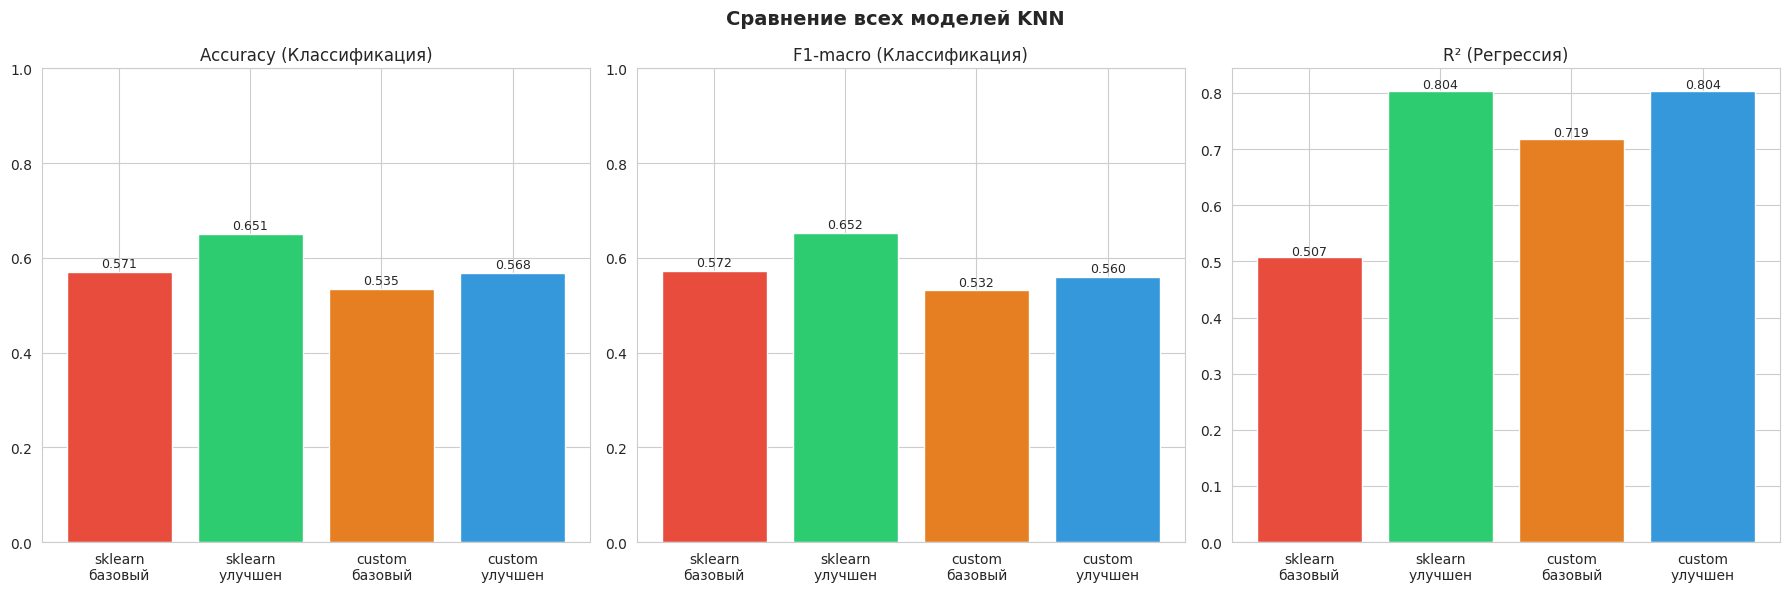

In [ ]:
# Финальная визуализация сравнения всех моделей
# Позволяет наглядно оценить влияние каждого улучшения

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

labels = ['sklearn\nбазовый', 'sklearn\nулучшен', 'custom\nбазовый', 'custom\nулучшен']
colors = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']

# Accuracy
acc_vals = [acc_baseline, acc_improved, acc_my_base, acc_my_improved]
bars = axes[0].bar(labels, acc_vals, color=colors)
axes[0].set_title('Accuracy (Классификация)')
axes[0].set_ylim(0, 1)
for b in bars: axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', fontsize=9)

# F1-macro
f1_vals = [f1_baseline, f1_improved, f1_my_base, f1_my_improved]
bars = axes[1].bar(labels, f1_vals, color=colors)
axes[1].set_title('F1-macro (Классификация)')
axes[1].set_ylim(0, 1)
for b in bars: axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.3f}', ha='center', fontsize=9)

# R²
r2_vals = [r2_baseline, r2_improved, r2_my_base, r2_my_improved]
bars = axes[2].bar(labels, r2_vals, color=colors)
axes[2].set_title('R² (Регрессия)')
for b in bars: axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005, f'{b.get_height():.3f}', ha='center', fontsize=9)

plt.suptitle('Сравнение всех моделей KNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Итоговые выводы

### 3g. Выводы по улучшению sklearn бейзлайна:
- **Масштабирование** (`StandardScaler`) — ключевое улучшение для KNN, так как алгоритм основан на расстояниях.
- **Подбор k** через 5-fold CV устранил случайность выбора гиперпараметра.
- **Взвешивание по расстоянию** улучшило качество, давая больший вес ближайшим соседям.
- **Создание признака BMI** добавило информативный составной признак для задачи классификации физической формы.

### 4e. Выводы по собственной имплементации vs sklearn:
- Собственная реализация воспроизводит поведение sklearn KNN с незначительными отличиями (небольшие расхождения из-за использования подвыборки).
- Расчёт расстояний реализован через векторные операции NumPy, что обеспечивает разумную скорость.
- Поддержка весов `distance` реализована через `1/d`, что совпадает с подходом sklearn.

### 4j. Выводы по применению улучшений к собственной имплементации:
- Применение оптимальных гиперпараметров (найденных GridSearchCV) к собственной реализации улучшило качество аналогично тому, как это произошло в sklearn.
- Выбор метрики расстояния (евклидова vs манхэттенская) влияет на результат: манхэттенская устойчивее к выбросам.
- Собственная реализация подтвердила корректность алгоритма и дала сопоставимые с sklearn результаты, что свидетельствует о правильности реализации.